In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(
    "../data/processed/vacancies_clean.csv"
)

df_skills = pd.read_csv(
    "../data/processed/vacancies_skills_clean.csv"
)

In [6]:
print("Основной датасет:", df.shape)
print("Skills dataset:", df_skills.shape)

Основной датасет: (527, 90)
Skills dataset: (516, 90)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 90 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            527 non-null    str  
 1   company          526 non-null    str  
 2   address          527 non-null    str  
 3   experience       527 non-null    str  
 4   url              527 non-null    str  
 5   query            527 non-null    str  
 6   page             527 non-null    int64
 7   vacancy_id       527 non-null    int64
 8   matched_queries  527 non-null    str  
 9   description      524 non-null    str  
 10  skills           527 non-null    str  
 11  skills_count     527 non-null    int64
 12  python           527 non-null    int64
 13  r                527 non-null    int64
 14  java             527 non-null    int64
 15  scala            527 non-null    int64
 16  cpp              527 non-null    int64
 17  pandas           527 non-null    int64
 18  numpy            527 

In [8]:
df.head()

,title,company,address,experience,url,query,page,vacancy_id,matched_queries,description,...,flask,django,rest_api,jupyter,notebook,sas,spss,title_clean,role,role_v1
0,Data Ananlyst / Аналитик Данных,Ventra,Москва,Опыт 1-3 года,https://hh.ru/vacancy/136031153?query=Data+Ana...,Data Analyst,0,136031153,"['BI Analyst', 'Data Analyst']",Мы – HR-холдинг Ventra. Уже более 22 лет мы сп...,...,0,0,0,0,0,0,0,data ananlyst / аналитик данных,Data Analyst,Data Analyst
1,Аналитик данных,RUTUBE,Москва,Опыт 1-3 года,https://hh.ru/vacancy/136365089?query=Data+Ana...,Data Analyst,0,136365089,['Data Analyst'],Новая локация офиса: В ноябре переезжаем в нов...,...,0,0,0,0,0,0,0,аналитик данных,Data Analyst,Data Analyst
2,Специалист по управлению данными / Аналитик да...,ООО Бюро Цифровой Трансформации,Москва,Опыт 1-3 года,https://hh.ru/vacancy/136299705?query=Data+Ana...,Data Analyst,0,136299705,"['BI Analyst', 'Data Analyst', 'Data Engineer']",Твои задачи: Работа с данными: Реализация шабл...,...,0,0,0,0,0,0,0,специалист по управлению данными / аналитик да...,Data Engineer,Data Engineer
3,Аналитик данных (Power BI),TraffCloud,Москва,Опыт 3-6 лет,https://hh.ru/vacancy/136329784?query=Data+Ana...,Data Analyst,0,136329784,['Data Analyst'],Мы - продуктовая компания в сфере онлайн-развл...,...,0,0,0,0,0,0,0,аналитик данных (power bi),Data Analyst,Data Analyst
4,Руководитель аналитики данных,ООО Альфа-Мобайл,Москва,Опыт 3-6 лет,https://hh.ru/vacancy/136187215?query=Data+Ana...,Data Analyst,0,136187215,['Data Analyst'],Команда АЛЬФА-МОБАЙЛ это мобильный виртуальный...,...,0,0,0,0,0,0,0,руководитель аналитики данных,Data Analyst,Other


In [9]:
role_counts = (
    df["role"]
    .value_counts()
)

print(role_counts)

role
Data Analyst        124
ML Engineer          91
Data Scientist       82
Data Engineer        64
AI Engineer          53
Python Developer     46
BI Analyst           38
MLOps Engineer       29
Name: count, dtype: int64


In [10]:
role_percent = (
    df["role"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(role_percent)

role
Data Analyst        23.5
ML Engineer         17.3
Data Scientist      15.6
Data Engineer       12.1
AI Engineer         10.1
Python Developer     8.7
BI Analyst           7.2
MLOps Engineer       5.5
Name: proportion, dtype: float64


In [11]:
role_summary = pd.DataFrame({
    "count": role_counts,
    "percent": role_percent
})

display(role_summary)

,count,percent
role,,
Data Analyst,124,23.5
ML Engineer,91,17.3
Data Scientist,82,15.6
Data Engineer,64,12.1
AI Engineer,53,10.1
Python Developer,46,8.7
BI Analyst,38,7.2
MLOps Engineer,29,5.5


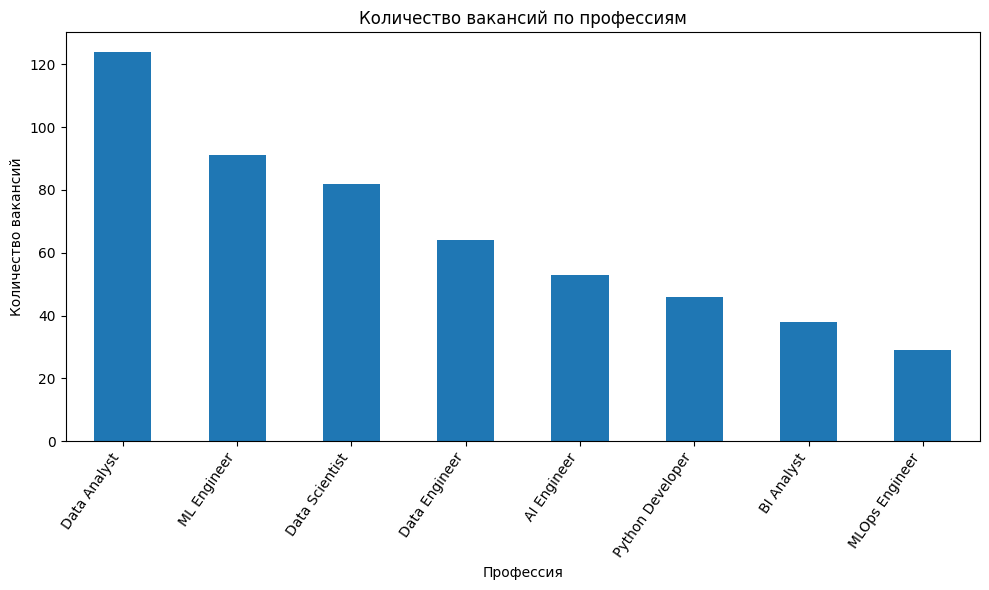

In [19]:
role_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Количество вакансий по профессиям"
)

plt.xlabel(
    "Профессия"
)

plt.ylabel(
    "Количество вакансий"
)

plt.xticks(
    rotation=55,
    ha="right"
)

plt.tight_layout()

plt.show()

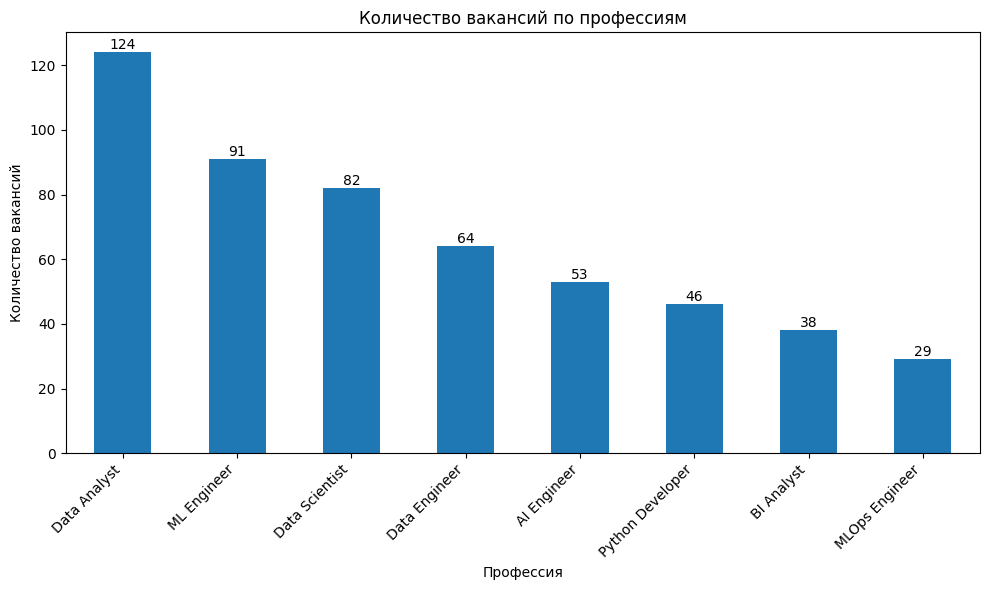

In [23]:
ax = role_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Количество вакансий по профессиям"
)

plt.xlabel("Профессия")
plt.ylabel("Количество вакансий")

plt.xticks(
    rotation=45,
    ha="right"
)

for container in ax.containers:
   ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/role_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
print(
    df["experience"]
    .value_counts()
)

experience
Опыт 3-6 лет        274
Опыт 1-3 года       180
Опыт более 6 лет     49
Без опыта            24
Name: count, dtype: int64


In [25]:
experience_counts = (
    df["experience"]
    .value_counts()
)

print(experience_counts)

experience
Опыт 3-6 лет        274
Опыт 1-3 года       180
Опыт более 6 лет     49
Без опыта            24
Name: count, dtype: int64


In [26]:
experience_percent = (
    df["experience"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(experience_percent)

experience
Опыт 3-6 лет        52.0
Опыт 1-3 года       34.2
Опыт более 6 лет     9.3
Без опыта            4.6
Name: proportion, dtype: float64


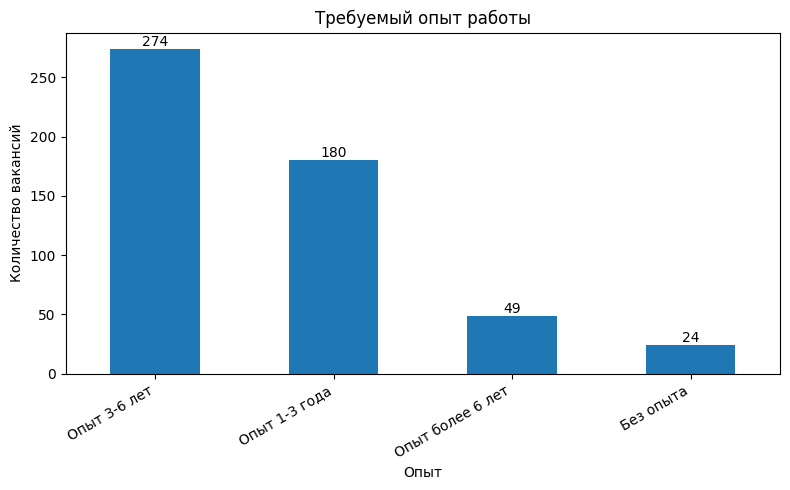

In [27]:
ax = experience_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Требуемый опыт работы"
)

plt.xlabel(
    "Опыт"
)

plt.ylabel(
    "Количество вакансий"
)

plt.xticks(
    rotation=30,
    ha="right"
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/experience_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
role_experience = pd.crosstab(
    df["role"],
    df["experience"]
)

display(role_experience)

experience,Без опыта,Опыт 1-3 года,Опыт 3-6 лет,Опыт более 6 лет
role,,,,
AI Engineer,1,18,28,6
BI Analyst,2,17,19,0
Data Analyst,4,55,57,8
Data Engineer,4,19,35,6
Data Scientist,5,21,44,12
ML Engineer,3,29,53,6
MLOps Engineer,0,6,18,5
Python Developer,5,15,20,6


In [29]:
role_experience_percent = pd.crosstab(
    df["role"],
    df["experience"],
    normalize="index"
).mul(100).round(1)

display(role_experience_percent)

experience,Без опыта,Опыт 1-3 года,Опыт 3-6 лет,Опыт более 6 лет
role,,,,
AI Engineer,1.9,34.0,52.8,11.3
BI Analyst,5.3,44.7,50.0,0.0
Data Analyst,3.2,44.4,46.0,6.5
Data Engineer,6.2,29.7,54.7,9.4
Data Scientist,6.1,25.6,53.7,14.6
ML Engineer,3.3,31.9,58.2,6.6
MLOps Engineer,0.0,20.7,62.1,17.2
Python Developer,10.9,32.6,43.5,13.0


In [30]:
SKILLS = {

    # -------------------------
    # Programming
    # -------------------------
    "python": [
        "python"
    ],

    "r": [
        " r ",
        "r language",
        "язык r"
    ],

    "java": [
        "java"
    ],

    "scala": [
        "scala"
    ],

    "cpp": [
        "c++"
    ],


    # -------------------------
    # Data analysis
    # -------------------------
    "pandas": [
        "pandas"
    ],

    "numpy": [
        "numpy"
    ],

    "scipy": [
        "scipy"
    ],

    "statsmodels": [
        "statsmodels"
    ],


    # -------------------------
    # Visualization
    # -------------------------
    "matplotlib": [
        "matplotlib"
    ],

    "seaborn": [
        "seaborn"
    ],

    "plotly": [
        "plotly"
    ],


    # -------------------------
    # BI
    # -------------------------
    "power_bi": [
        "power bi",
        "powerbi"
    ],

    "tableau": [
        "tableau"
    ],

    "excel": [
        "excel",
        "ms excel",
        "microsoft excel"
    ],

    "power_query": [
        "power query"
    ],

    "dax": [
        "dax"
    ],

    "looker": [
        "looker",
        "looker studio"
    ],

    "qlik": [
        "qlik",
        "qlik sense",
        "qlikview"
    ],

    "metabase": [
        "metabase"
    ],


    # -------------------------
    # SQL / Databases
    # -------------------------
    "sql": [
        "sql"
    ],

    "postgresql": [
        "postgresql",
        "postgres"
    ],

    "mysql": [
        "mysql"
    ],

    "ms_sql_server": [
        "mssql",
        "ms sql",
        "ms sql server",
        "microsoft sql server",
        "sql server"
    ],

    "oracle": [
        "oracle database",
        "oracle db"
    ],

    "clickhouse": [
        "clickhouse"
    ],

    "mongodb": [
        "mongodb",
        "mongo db"
    ],

    "redis": [
        "redis"
    ],

    "sqlite": [
        "sqlite"
    ],


    # -------------------------
    # Classical Machine Learning
    # -------------------------
    "scikit_learn": [
        "scikit-learn",
        "scikit learn",
        "sklearn"
    ],

    "xgboost": [
        "xgboost"
    ],

    "lightgbm": [
        "lightgbm",
        "light gbm"
    ],

    "catboost": [
        "catboost"
    ],


    # -------------------------
    # Deep Learning
    # -------------------------
    "pytorch": [
        "pytorch",
        "torch"
    ],

    "tensorflow": [
        "tensorflow"
    ],

    "keras": [
        "keras"
    ],


    # -------------------------
    # Computer Vision
    # -------------------------
    "opencv": [
        "opencv",
        "open cv"
    ],

    "yolo": [
        "yolo"
    ],


    # -------------------------
    # NLP / LLM
    # -------------------------
    "nlp": [
        "nlp",
        "natural language processing"
    ],

    "transformers": [
        "transformers"
    ],

    "huggingface": [
        "hugging face",
        "huggingface"
    ],

    "llm": [
        "llm",
        "large language model",
        "large language models"
    ],

    "rag": [
        "rag",
        "retrieval augmented generation",
        "retrieval-augmented generation"
    ],

    "langchain": [
        "langchain"
    ],

    "llamaindex": [
        "llamaindex",
        "llama index"
    ],

    "openai_api": [
        "openai api"
    ],


    # -------------------------
    # Big Data / Data Engineering
    # -------------------------
    "spark": [
        "apache spark",
        "pyspark",
        "spark"
    ],

    "hadoop": [
        "hadoop"
    ],

    "kafka": [
        "apache kafka",
        "kafka"
    ],

    "airflow": [
        "apache airflow",
        "airflow"
    ],

    "dbt": [
        "dbt",
        "data build tool"
    ],

    "hive": [
        "apache hive",
        "hive"
    ],

    "snowflake": [
        "snowflake"
    ],

    "bigquery": [
        "bigquery",
        "big query"
    ],

    "databricks": [
        "databricks"
    ],


    # -------------------------
    # MLOps / DevOps
    # -------------------------
    "docker": [
        "docker"
    ],

    "kubernetes": [
        "kubernetes",
        "k8s"
    ],

    "mlflow": [
        "mlflow"
    ],

    "dvc": [
        "dvc",
        "data version control"
    ],

    "git": [
        "git"
    ],

    "github": [
        "github"
    ],

    "gitlab": [
        "gitlab"
    ],

    "jenkins": [
        "jenkins"
    ],

    "ci_cd": [
        "ci/cd",
        "ci cd",
        "continuous integration"
    ],


    # -------------------------
    # Cloud
    # -------------------------
    "aws": [
        "aws",
        "amazon web services"
    ],

    "azure": [
        "microsoft azure",
        "azure"
    ],

    "gcp": [
        "gcp",
        "google cloud",
        "google cloud platform"
    ],


    # -------------------------
    # Backend / API
    # -------------------------
    "fastapi": [
        "fastapi",
        "fast api"
    ],

    "flask": [
        "flask"
    ],

    "django": [
        "django"
    ],

    "rest_api": [
        "rest api",
        "restful",
        "rest-api"
    ],


    # -------------------------
    # Other analytics tools
    # -------------------------
    "jupyter": [
        "jupyter",
        "jupyter notebook"
    ],

    "notebook": [
        "notebook"
    ],

    "sas": [
        "sas"
    ],

    "spss": [
        "spss"
    ]
}
skill_columns = list(SKILLS.keys())

In [31]:
skill_counts = (
    df_skills[skill_columns]
    .sum()
    .sort_values(ascending=False)
)

print(skill_counts.head(30))

python          436
sql             317
llm             164
docker          161
airflow         145
git             141
postgresql      138
pandas          134
spark           110
ci_cd           106
pytorch         105
rag             104
fastapi          95
kubernetes       95
numpy            88
power_bi         86
clickhouse       83
scikit_learn     79
kafka            72
nlp              67
excel            64
langchain        63
tableau          60
hadoop           57
mlflow           57
gitlab           54
tensorflow       48
redis            41
rest_api         40
aws              38
dtype: int64


In [32]:
skill_percent = (
    df_skills[skill_columns]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(skill_percent.head(30).round(1))

python          84.5
sql             61.4
llm             31.8
docker          31.2
airflow         28.1
git             27.3
postgresql      26.7
pandas          26.0
spark           21.3
ci_cd           20.5
pytorch         20.3
rag             20.2
fastapi         18.4
kubernetes      18.4
numpy           17.1
power_bi        16.7
clickhouse      16.1
scikit_learn    15.3
kafka           14.0
nlp             13.0
excel           12.4
langchain       12.2
tableau         11.6
hadoop          11.0
mlflow          11.0
gitlab          10.5
tensorflow       9.3
redis            7.9
rest_api         7.8
aws              7.4
dtype: float64


In [33]:
top_skills = skill_percent.head(20)

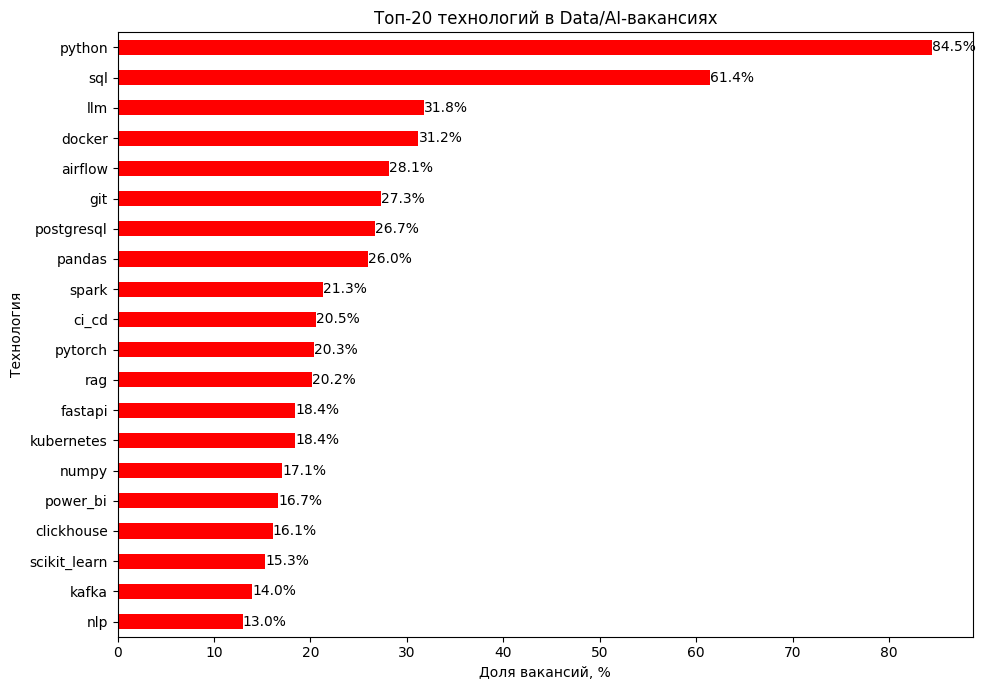

In [41]:
ax = top_skills.sort_values().plot(
    kind="barh",
    figsize=(10, 7),
    color = 'red'
)

plt.title(
    "Топ-20 технологий в Data/AI-вакансиях"
)

plt.xlabel(
    "Доля вакансий, %"
)

plt.ylabel(
    "Технология"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()

plt.savefig(
    "../images/top_skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
skills_by_role = (
    df_skills
    .groupby("role")[skill_columns]
    .mean()
    .mul(100)
)

display(skills_by_role)

,python,r,java,scala,cpp,pandas,numpy,scipy,statsmodels,matplotlib,...,azure,gcp,fastapi,flask,django,rest_api,jupyter,notebook,sas,spss
role,,,,,,,,,,,,,,,,,,,,,
AI Engineer,84.615385,11.538462,3.846154,0.000000,0.000000,19.230769,13.461538,3.846154,0.000000,1.923077,...,5.769231,7.692308,48.076923,9.615385,5.769231,26.923077,0.000000,0.000000,0.000000,0.0
BI Analyst,54.054054,5.405405,0.000000,0.000000,0.000000,13.513514,8.108108,2.702703,2.702703,2.702703,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.702703,2.702703,2.702703,0.000000,0.0
Data Analyst,79.831933,5.882353,1.680672,1.680672,0.000000,35.294118,21.848739,7.563025,4.201681,10.084034,...,0.840336,0.000000,0.840336,0.840336,0.840336,0.840336,3.361345,0.840336,0.840336,0.0
Data Engineer,85.937500,1.562500,7.812500,12.500000,0.000000,18.750000,4.687500,0.000000,0.000000,0.000000,...,4.687500,4.687500,12.500000,3.125000,1.562500,4.687500,3.125000,0.000000,3.125000,0.0
Data Scientist,91.358025,7.407407,0.000000,0.000000,2.469136,40.740741,34.567901,3.703704,4.938272,7.407407,...,0.000000,1.234568,14.814815,4.938272,2.469136,1.234568,6.172840,3.703704,0.000000,0.0
ML Engineer,90.909091,7.954545,4.545455,0.000000,6.818182,32.954545,23.863636,6.818182,2.272727,6.818182,...,5.681818,6.818182,21.590909,4.545455,0.000000,4.545455,1.136364,2.272727,0.000000,0.0
MLOps Engineer,79.310345,6.896552,6.896552,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,17.241379,27.586207,6.896552,0.000000,0.000000,3.448276,0.000000,0.000000,0.000000,0.0
Python Developer,97.826087,4.347826,4.347826,0.000000,6.521739,6.521739,0.000000,0.000000,0.000000,0.000000,...,2.173913,6.521739,60.869565,19.565217,36.956522,32.608696,0.000000,0.000000,0.000000,0.0


In [43]:
def top_skills_for_role(role, n=10):

    skills = (
        skills_by_role
        .loc[role]
        .sort_values(ascending=False)
        .head(n)
    )

    return skills

In [46]:
skills_by_role.loc["Data Scientist"]

python      91.358025
r            7.407407
java         0.000000
scala        0.000000
cpp          2.469136
              ...    
rest_api     1.234568
jupyter      6.172840
notebook     3.703704
sas          0.000000
spss         0.000000
Name: Data Scientist, Length: 75, dtype: float64

In [45]:
print(
    top_skills_for_role(
        "BI Analyst"
    )
)

sql              86.486486
power_bi         67.567568
python           54.054054
tableau          43.243243
postgresql       35.135135
excel            32.432432
clickhouse       21.621622
airflow          21.621622
ms_sql_server    21.621622
dax              18.918919
Name: BI Analyst, dtype: float64


In [47]:
for role in skills_by_role.index:

    print()
    print("=" * 60)
    print(role)
    print("=" * 60)

    print(
        top_skills_for_role(
            role,
            n=10
        ).round(1)
    )


AI Engineer
llm           86.5
python        84.6
rag           75.0
docker        65.4
langchain     51.9
fastapi       48.1
git           36.5
llamaindex    34.6
ci_cd         34.6
postgresql    32.7
Name: AI Engineer, dtype: float64

BI Analyst
sql              86.5
power_bi         67.6
python           54.1
tableau          43.2
postgresql       35.1
excel            32.4
clickhouse       21.6
airflow          21.6
ms_sql_server    21.6
dax              18.9
Name: BI Analyst, dtype: float64

Data Analyst
sql           92.4
python        79.8
power_bi      45.4
excel         37.0
pandas        35.3
tableau       32.8
postgresql    29.4
clickhouse    26.1
numpy         21.8
airflow       21.0
Name: Data Analyst, dtype: float64

Data Engineer
python        85.9
sql           84.4
airflow       76.6
postgresql    45.3
kafka         45.3
spark         43.8
clickhouse    40.6
git           39.1
ci_cd         28.1
dbt           26.6
Name: Data Engineer, dtype: float64

Data Scientist
py

In [49]:
top_20_skill_names = (
    skill_percent
    .head(20)
    .index
    .tolist()
)
heatmap_data = (
    skills_by_role[
        top_20_skill_names
    ]
)

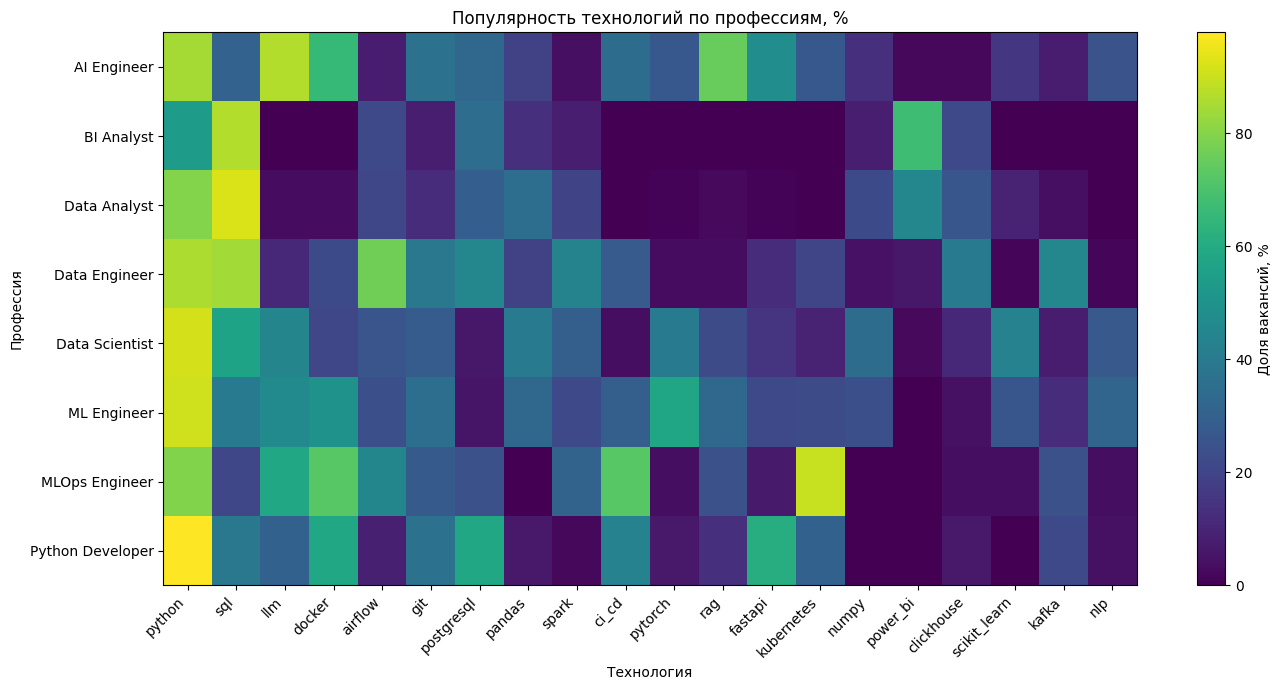

In [55]:
fig, ax = plt.subplots(
    figsize=(14, 7)
)

image = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(heatmap_data.columns))
)

ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(heatmap_data.index))
)

ax.set_yticklabels(
    heatmap_data.index
)



plt.title(
    "Популярность технологий по профессиям, %"
)

plt.xlabel(
    "Технология"
)

plt.ylabel(
    "Профессия"
)

plt.colorbar(
    image,
    label="Доля вакансий, %"
)




plt.tight_layout()

plt.savefig(
    "../images/skills_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
print(
    df_skills["skills_count"]
    .describe()
)

count    516.000000
mean       7.786822
std        4.305461
min        1.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       23.000000
Name: skills_count, dtype: float64


In [57]:
print(
    "Среднее:",
    df_skills["skills_count"].mean()
)

print(
    "Медиана:",
    df_skills["skills_count"].median()
)

print(
    "Стандартное отклонение:",
    df_skills["skills_count"].std()
)

Среднее: 7.786821705426356
Медиана: 7.0
Стандартное отклонение: 4.305460607632763


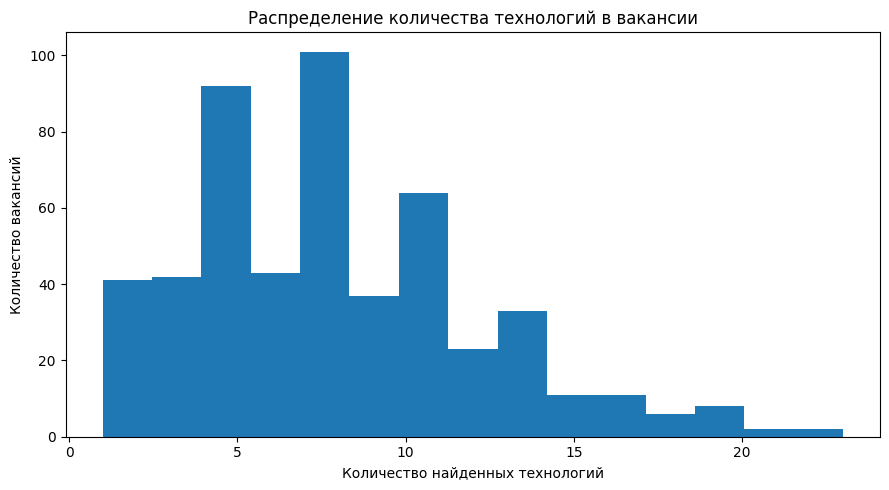

In [58]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    df_skills["skills_count"],
    bins=15
)

plt.title(
    "Распределение количества технологий в вакансии"
)

plt.xlabel(
    "Количество найденных технологий"
)

plt.ylabel(
    "Количество вакансий"
)

plt.tight_layout()

plt.savefig(
    "../images/skills_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
skills_count_by_role = (
    df_skills
    .groupby("role")["skills_count"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
    .round(2)
)

display(
    skills_count_by_role
)

,count,mean,median,std
role,,,,
AI Engineer,52,9.31,9.0,4.63
BI Analyst,37,5.30,5.0,3.11
Data Analyst,119,6.39,6.0,3.66
Data Engineer,64,8.03,7.5,4.00
Data Scientist,81,8.19,8.0,4.20
ML Engineer,88,8.78,8.0,4.99
MLOps Engineer,29,9.03,8.0,3.85
Python Developer,46,7.96,7.0,4.21


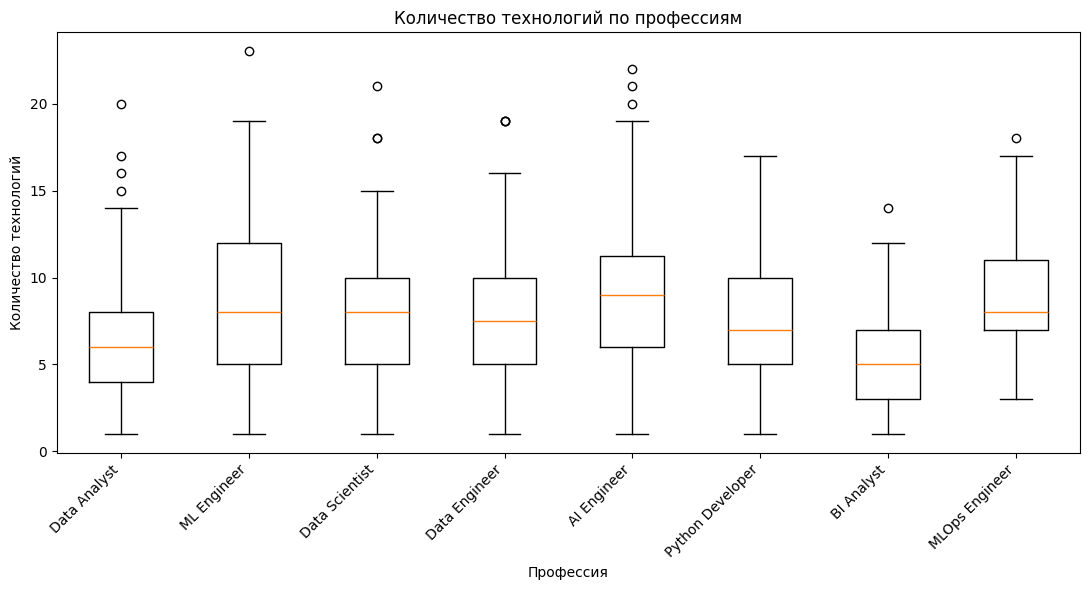

In [60]:
roles = (
    df_skills["role"]
    .value_counts()
    .index
    .tolist()
)

data_for_boxplot = [
    df_skills.loc[
        df_skills["role"] == role,
        "skills_count"
    ]
    for role in roles
]

plt.figure(
    figsize=(11, 6)
)

plt.boxplot(
    data_for_boxplot,
    tick_labels=roles
)

plt.title(
    "Количество технологий по профессиям"
)

plt.xlabel(
    "Профессия"
)

plt.ylabel(
    "Количество технологий"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "../images/skills_count_by_role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
from scipy import stats

In [ ]:
skills_skew = df_skills["skills_count"].skew()
skills_kurt = df_skills["skills_count"].kurt()

print("Skewness:", round(skills_skew, 3))
print("Kurtosis:", round(skills_kurt, 3))
#длинный хвост в право

Skewness: 0.756
Kurtosis: 0.38


### Формулируем гипотезы:
#### H0:распределение skills_count нормально
#### H1:распределение skills_count отличается от нормального

In [ ]:
shapiro_result = stats.shapiro(
    df_skills["skills_count"]
)

print(
    "Statistic:",
    round(shapiro_result.statistic, 4)
)

print(
    "p-value:",
    shapiro_result.pvalue
)
#отвергаем н0 и принимаем н1

Statistic: 0.9542
p-value: 1.441399878334774e-11


In [64]:
for role in df_skills["role"].unique():

    values = df_skills.loc[
        df_skills["role"] == role,
        "skills_count"
    ]

    result = stats.shapiro(values)

    print(
        role,
        "n =", len(values),
        "p =", round(result.pvalue, 4)
    )

Data Analyst n = 119 p = 0.0
Data Engineer n = 64 p = 0.0032
Data Scientist n = 81 p = 0.0209
Python Developer n = 46 p = 0.0432
ML Engineer n = 88 p = 0.0227
AI Engineer n = 52 p = 0.0149
BI Analyst n = 37 p = 0.0156
MLOps Engineer n = 29 p = 0.3346


In [65]:
skill_groups = []

role_names = []

for role in df_skills["role"].unique():

    values = df_skills.loc[
        df_skills["role"] == role,
        "skills_count"
    ]

    skill_groups.append(values)

    role_names.append(role)

## H0:распределения skills_count одинаковы для всех профессий
## H1:хотя бы одна профессия отличается

In [ ]:
kruskal_result = stats.kruskal(
    *skill_groups
)

print(
    "H statistic:",
    round(kruskal_result.statistic, 4)
)

print(
    "p-value:",
    kruskal_result.pvalue
)
#н0 отвергаем

H statistic: 43.0142
p-value: 3.3146771992437984e-07


In [68]:
#мана уитни попоарно
from itertools import combinations
pairwise_results = []

roles = sorted(
    df_skills["role"].unique()
)

for role_1, role_2 in combinations(roles, 2):

    group_1 = df_skills.loc[
        df_skills["role"] == role_1,
        "skills_count"
    ]

    group_2 = df_skills.loc[
        df_skills["role"] == role_2,
        "skills_count"
    ]

    result = stats.mannwhitneyu(
        group_1,
        group_2,
        alternative="two-sided"
    )

    pairwise_results.append({
        "role_1": role_1,
        "role_2": role_2,
        "p_value": result.pvalue
    })

In [69]:
pairwise_df = pd.DataFrame(
    pairwise_results
)

display(
    pairwise_df
    .sort_values("p_value")
)

,role_1,role_2,p_value
0,AI Engineer,BI Analyst,0.000008
1,AI Engineer,Data Analyst,0.000022
11,BI Analyst,MLOps Engineer,0.000062
10,BI Analyst,ML Engineer,0.000144
9,BI Analyst,Data Scientist,0.000260
15,Data Analyst,ML Engineer,0.000368
8,BI Analyst,Data Engineer,0.000422
16,Data Analyst,MLOps Engineer,0.000576
14,Data Analyst,Data Scientist,0.001510
12,BI Analyst,Python Developer,0.002316


In [ ]:
#коррекция холм
#Если сравниваем много пар, вероятность случайно получить возрастает. Поэтому надо сделать коррекцию. Для 8 профессий количество пар
# Покажет только статистически значимые различия.
from statsmodels.stats.multitest import multipletests
reject, p_corrected, _, _ = multipletests(
    pairwise_df["p_value"],
    alpha=0.05,
    method="holm"
)

pairwise_df["p_corrected"] = p_corrected
pairwise_df["significant"] = reject

display(
    pairwise_df[
        pairwise_df["significant"]
    ].sort_values(
        "p_corrected"
    )
)

,role_1,role_2,p_value,p_corrected,significant
0,AI Engineer,BI Analyst,0.000008,0.000232,True
1,AI Engineer,Data Analyst,0.000022,0.000584,True
11,BI Analyst,MLOps Engineer,0.000062,0.001625,True
10,BI Analyst,ML Engineer,0.000144,0.003595,True
9,BI Analyst,Data Scientist,0.000260,0.006240,True
15,Data Analyst,ML Engineer,0.000368,0.008468,True
8,BI Analyst,Data Engineer,0.000422,0.009293,True
16,Data Analyst,MLOps Engineer,0.000576,0.012099,True
14,Data Analyst,Data Scientist,0.001510,0.030207,True
12,BI Analyst,Python Developer,0.002316,0.043997,True


## H0:профессия и требуемый опыт независимы

## H1:между профессией и опытом существует связь

In [71]:
experience_table = pd.crosstab(
    df["role"],
    df["experience"]
)

display(experience_table)

chi2, p_value, dof, expected = (
    stats.chi2_contingency(
        experience_table
    )
)

experience,Без опыта,Опыт 1-3 года,Опыт 3-6 лет,Опыт более 6 лет
role,,,,
AI Engineer,1,18,28,6
BI Analyst,2,17,19,0
Data Analyst,4,55,57,8
Data Engineer,4,19,35,6
Data Scientist,5,21,44,12
ML Engineer,3,29,53,6
MLOps Engineer,0,6,18,5
Python Developer,5,15,20,6


In [72]:
print(
    "Chi-square:",
    round(chi2, 3)
)

print(
    "p-value:",
    p_value
)

print(
    "Degrees of freedom:",
    dof
)

Chi-square: 30.373
p-value: 0.0847432571032592
Degrees of freedom: 21


## Профессия и требуемый опыт независимы

Критерий χ² предполагает, что ожидаемые частоты не слишком маленькие.


In [73]:
expected_df = pd.DataFrame(
    expected,
    index=experience_table.index,
    columns=experience_table.columns
)

display(expected_df.round(2))

small_expected = (
    expected_df < 5
).sum().sum()

print(
    "Ячеек с expected < 5:",
    small_expected
)

experience,Без опыта,Опыт 1-3 года,Опыт 3-6 лет,Опыт более 6 лет
role,,,,
AI Engineer,2.41,18.10,27.56,4.93
BI Analyst,1.73,12.98,19.76,3.53
Data Analyst,5.65,42.35,64.47,11.53
Data Engineer,2.91,21.86,33.28,5.95
Data Scientist,3.73,28.01,42.63,7.62
ML Engineer,4.14,31.08,47.31,8.46
MLOps Engineer,1.32,9.91,15.08,2.70
Python Developer,2.09,15.71,23.92,4.28


Ячеек с expected < 5: 11


### Требуют ли вакансии с большим опытом больше технологий?

In [74]:
print(
    df_skills["experience"]
    .value_counts()
)

experience
Опыт 3-6 лет        271
Опыт 1-3 года       175
Опыт более 6 лет     47
Без опыта            23
Name: count, dtype: int64


In [78]:
EXPERIENCE_MAP = {
    "Без опыта": 0,
    "Опыт 1-3 года": 1,
    "Опыт 3-6 лет": 2,
    "Опыт более 6 лет": 3
}

In [ ]:
df_skills["experience_level"] = (
    df_skills["experience"]
    .map(EXPERIENCE_MAP)
)

In [80]:
display(
    df_skills[
        [
            "experience",
            "experience_level"
        ]
    ].drop_duplicates()
)

,experience,experience_level
0,Опыт 1-3 года,1.0
3,Опыт 3-6 лет,2.0
9,Без опыта,0.0
11,Опыт более 6 лет,NaN


In [81]:
df_skills["experience_clean"] = (
    df_skills["experience"]
    .str.replace("\u00A0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [82]:
print(
    df_skills["experience_clean"]
    .value_counts()
)

experience_clean
Опыт 3-6 лет        271
Опыт 1-3 года       175
Опыт более 6 лет     47
Без опыта            23
Name: count, dtype: int64


In [83]:
EXPERIENCE_MAP = {
    "Без опыта": 0,
    "Опыт 1-3 года": 1,
    "Опыт 3-6 лет": 2,
    "Опыт более 6 лет": 3
}

df_skills["experience_level"] = (
    df_skills["experience_clean"]
    .map(EXPERIENCE_MAP)
)

In [84]:
display(
    df_skills[
        [
            "experience",
            "experience_clean",
            "experience_level"
        ]
    ]
    .drop_duplicates()
    .sort_values("experience_level")
)

,experience,experience_clean,experience_level
9,Без опыта,Без опыта,0
0,Опыт 1-3 года,Опыт 1-3 года,1
3,Опыт 3-6 лет,Опыт 3-6 лет,2
11,Опыт более 6 лет,Опыт более 6 лет,3


In [85]:
print(
    "NaN:",
    df_skills["experience_level"]
    .isna()
    .sum()
)

NaN: 0


In [86]:
spearman_result = stats.spearmanr(
    df_skills["experience_level"],
    df_skills["skills_count"]
)

print(
    "Spearman rho:",
    round(
        spearman_result.statistic,
        3
    )
)

print(
    "p-value:",
    spearman_result.pvalue
)

Spearman rho: 0.085
p-value: 0.05333788361068856


В выборке наблюдается очень слабая положительная связь между требуемым опытом и количеством обнаруженных технологий (ρ=0.085), однако на уровне значимости 0.05 эта связь статистически незначима (p=0.053).

Фактически вакансия с опытом 3–6 лет не обязательно содержит намного больше технологий, чем вакансия 1–3 года.